# Thesis Figures

In [32]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
from scipy import stats
import matplotlib.ticker as ticker
import scipy.signal as peak
from scipy.optimize import curve_fit

# append parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")

# import functions!!
import qil_helpers.Angela.angelaHelpers as ang 

## Functions

In [108]:
def plot_double_spectrum(freqs, cps, T1s, T1errs,
                         cols, figsize, site, timeLimit, 
                         y0Ticks, y1Ticks, y0lims, y1lims,
                         freqOffset = None, lines = True, norm = True, fits = None,
                         save = False, savePath = None, xLabel = None, plotDesc = None):

    c = 299792458  # m/s

    def freq_to_wavelength(f_GHz):
        return c / (f_GHz * 1e9) * 1e9  # → nm

    def wavelength_to_freq(l_nm):
        return c / (l_nm * 1e-9) / 1e9  # → GHz

    fig, (ax0, ax1) = plt.subplots(
        2, 1,
        figsize = (figsize[0], figsize[1]),
        gridspec_kw = {'height_ratios': [2, 1]},
        sharex = True
    )

    if y0lims is not None:
        mask = (y0lims[0] <= cps) & (cps < y0lims[1])
        cps = cps[mask]
        freqs = freqs[mask]
        T1s = T1s[mask]
        T1errs = T1errs[mask]

    # COUNTS VS FREQUENCY
    if norm == False:
        ax0.set_ylabel(fr'Count Rate (s$^{-1}$)', fontsize = 14)
    if norm:
        cps = cps / max(cps)
        cpsRange = max(cps) - min(cps)
        ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = 14)
    minLim = min(cps) - 0.1 * cpsRange
    maxLim = max(cps) + 0.1 * cpsRange
    # ax0.scatter(freqs, cps/sorted(cps)[-2], c = cols[0], s = 8)
    ax0.scatter(freqs, cps, c = cols[0], s = 8 )
    ax0.tick_params(axis = 'both', labelsize = 12) 
    ax0.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
    ax0.set_ylim([minLim, maxLim])
    secax = ax0.secondary_xaxis(
        'top',
        functions=(freq_to_wavelength, wavelength_to_freq)
    )
    secax.set_xlabel('Wavelength (nm)', fontsize = 14)
    secax.tick_params(axis = 'x', labelsize = 12)  
    secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 

    # PLOT LINES
    if lines:
          ax0.vlines((site[1]/1e3), minLim, maxLim,
                    colors = cols[1], linewidth = 1,
                    label = f'Published f$_0$')
          
    # PLOT FIT
    if fits is not None:
          xFit = np.linspace(min(freqs), max(freqs), 500)
          x0 = fits['x0']
          x0_err = fits['x0_err']
          gamma = fits['gamma']
          gamma_err = fits['gamma_err']
          A = fits['A']
          B = fits['B']
          C = fits['C']
          lorentzianFitted = ang.asym_lorentzian(xFit, x0, gamma, A, B, C)
          
          if norm:
            ax0.vlines((x0), minLim, maxLim,
                        colors = cols[-1], linewidth = 1,
                        label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz' )
            ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                c = cols[2], linewidth = 1.5,
                label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')
          if norm == False:
            ax0.vlines((x0), minLim, maxLim,
                colors = cols[2], linewidth = 1,
                label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz')    
            ax0.plot(xFit, lorentzianFitted,
                c = cols[2], linewidth = 1.5,
                label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')          

    # LIFETIME VS FREQUENCY
    ax1.scatter(freqs, T1s,
                c = 'OrangeRed', s = 5,
                label = fr'T$_1$')
    T1Range = max(T1s) - min(T1s)
    ax1.set_ylim([min(T1s) - 0.2 * T1Range, max(T1s) + 0.2 * T1Range])

    T1errs = abs(T1errs)
    for i, T1err in enumerate(T1errs):
        if T1err > 5:
            T1errs[i] = 0
    ax1.set_xlabel('Frequency (GHz)', fontsize = 14)
    ax1.set_ylabel(rf'T$_1$ (ms)', fontsize = 14)
    ax1.tick_params(axis = 'both', labelsize = 12) 
    ax1.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
    ax1.fill_between(freqs,
                    T1s - T1errs,
                    T1s + T1errs,
                    color = cols[1],
                    alpha = 0.4,
                    linewidth = 0,
                    label = r"T$_1$ standard error")
    
    if y1lims is not None:
        ax1.set_ylim([y1lims[0], y1lims[1]])
        
# ##########################################################################
# ##########################################################################
#     ax0.yaxis.set_major_locator(ticker.MultipleLocator(y0Ticks[0]))
#     ax0.yaxis.set_minor_locator(ticker.MultipleLocator(y0Ticks[1]))
#     ###############################################################
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(y1Ticks[0]))
    ax1.yaxis.set_minor_locator(ticker.MultipleLocator(y1Ticks[1]))
# ##########################################################################
# ##########################################################################

# FORMATTING   
    ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax1.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax0.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    ax0.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
    ax1.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    ax1.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)

    if plotDesc is None:
        plt.suptitle(fr'{site[0]}', fontsize = 18)
    else:
        plt.suptitle(fr'{plotDesc}', fontsize = 18)

    ax0.legend(fontsize = 14, borderaxespad = 1, loc = 'upper left')
    ax1.legend(fontsize = 14, markerscale = 3, borderaxespad = 1, loc = 'upper left')

    ######################################################################
    # ax0.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    # ax1.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    # ax2.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    ######################################################################
    plt.tight_layout()

    if save:
          os.makedirs(savePath, exist_ok = True)
          save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz_multi.png')
          plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')

    plt.show()

In [34]:
def plot_multi_spectrum(freqs, cps, T1s, T1errs,
                         cols, figsize, site, timeLimit, ylims,
                         y0Ticks, y1Ticks, y2Ticks,
                         freqOffset = None, lines = True, norm = True, fits = None,
                         save = False, savePath = None, xLabel = None, plotDesc = None):

    c = 299792458  # m/s

    def freq_to_wavelength(f_GHz):
        return c / (f_GHz * 1e9) * 1e9  # → nm

    def wavelength_to_freq(l_nm):
        return c / (l_nm * 1e-9) / 1e9  # → GHz

    fig, (ax0, ax1, ax2) = plt.subplots(
        3, 1,
        figsize = (figsize[0], figsize[1]),
        gridspec_kw = {'height_ratios': [2, 1, 0.75]},
        sharex = True
    )

    if ylims is not None:
        mask = (ylims[0] <= cps) & (cps < ylims[1])
        cps = cps[mask]
        freqs = freqs[mask]
        T1s = T1s[mask]
        T1errs = T1errs[mask]

    # COUNTS VS FREQUENCY
    if norm == False:
        ax0.set_ylabel(fr'Count Rate (s$^{-1}$)', fontsize = 14)
    if norm:
        cps = cps / max(cps)
        cpsRange = max(cps) - min(cps)
        ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = 14)
    minLim = min(cps) - 0.1 * cpsRange
    maxLim = max(cps) + 0.1 * cpsRange
    ax0.scatter(freqs, cps, c = cols[0], s = 8)

    ######################################################################
    ax0.yaxis.set_major_locator(ticker.MultipleLocator(y0Ticks[0]))
    ax0.yaxis.set_minor_locator(ticker.MultipleLocator(y0Ticks[1]))
    ######################################################################
    ax0.tick_params(axis = 'both', labelsize = 12) 
    ax0.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
    ax0.set_ylim([minLim, maxLim])
    secax = ax0.secondary_xaxis(
        'top',
        functions=(freq_to_wavelength, wavelength_to_freq)
    )
    secax.set_xlabel('Wavelength (nm)', fontsize = 14)
    secax.tick_params(axis = 'x', labelsize = 12)  
    secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 

    # PLOT LINES
    if lines:
          ax0.vlines((site[1]/1e3), minLim, maxLim,
                    colors = cols[1], linewidth = 1,
                    label = f'Published f$_0$')
          
    # PLOT FIT
    if fits is not None:
          xFit = np.linspace(min(freqs), max(freqs), 500)
          x0 = fits['x0']
          x0_err = fits['x0_err']
          gamma = fits['gamma']
          gamma_err = fits['gamma_err']
          A = fits['A']
          B = fits['B']
          C = fits['C']
          lorentzianFitted = ang.asym_lorentzian(xFit, x0, gamma, A, B, C)
          
          if norm:
            ax0.vlines((x0), minLim, maxLim,
                        colors = cols[-1], linewidth = 1,
                        label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz' )
            ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                c = cols[2], linewidth = 1.5,
                label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')
          if norm == False:
            ax0.vlines((x0), minLim, maxLim,
                colors = cols[2], linewidth = 1,
                label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz')    
            ax0.plot(xFit, lorentzianFitted,
                c = cols[2], linewidth = 1.5,
                label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')          

    # LIFETIME VS FREQUENCY
    ax1.scatter(freqs, T1s,
                c = cols[1], s = 5)
    T1Range = max(T1s) - min(T1s)
    ax1.set_ylim([min(T1s) - 0.2 * T1Range, max(T1s) + 0.2 * T1Range])
    ######################################################################
    # ax1.set_ylim([0, 50])
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(y1Ticks[0]))
    ax1.yaxis.set_minor_locator(ticker.MultipleLocator(y1Ticks[1]))
    ######################################################################
    ax1.set_ylabel(rf'T$_1$ (ms)', fontsize = 14)
    ax1.tick_params(axis = 'both', labelsize = 12) 
    ax1.ticklabel_format(style = 'plain', useOffset = False, axis = 'both')   

    # ERROR VS FREQUENCY
    T1errs = abs(T1errs)
    ax2.scatter(freqs, T1errs,
                c = 'OrangeRed', s = 5)
    T1errRange = max(T1errs) - min(T1errs)
    ax2.set_ylim([min(T1errs) - 0.6 * T1errRange, max(T1errs) + 0.6 * T1errRange])
    ax2.set_xlabel('Frequency (GHz)', fontsize = 14)
    ax2.set_ylabel(rf'$\Delta$ T$_1$ (ms)', fontsize = 14)
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax2.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ######################################################################
    ax2.set_ylim([-2, 30])
    # ax2.yaxis.set_major_locator(ticker.MultipleLocator(y2Ticks[0]))
    # ax2.yaxis.set_minor_locator(ticker.MultipleLocator(y2Ticks[1]))
    ######################################################################
    ax2.tick_params(axis = 'both', labelsize = 12) 
    ax2.ticklabel_format(style = 'plain', useOffset = False, axis = 'both')   

    ax0.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    ax0.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
    ax1.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    ax1.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
    ax2.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    ax2.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
    if plotDesc is None:
        plt.suptitle(fr'{site[0]}', fontsize = 18)
    else:
        plt.suptitle(fr'{plotDesc}', fontsize = 18)

    ax0.legend(fontsize = 14, borderaxespad = 1, loc = 'upper left')
    ######################################################################
    # ax0.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    # ax1.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    # ax2.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    ######################################################################
    plt.tight_layout()

    if save:
          os.makedirs(savePath, exist_ok = True)
          save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz_multi.png')
          plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')

    plt.show()

In [35]:
def plot_single_spectrum(x, y, 
                         cols, figsize, site, timeLimit, ylims = None,
                         freqOffset = None, lines = True, norm = True, fits = None,
                         save = False, savePath = None, xLabel = None, plotDesc = None):
     
     # NORMALISE 
     if norm:
          y = y / np.max(y)
     range = max(y) - min(y)
     minLim = min(y) - 0.05 * range
     maxLim = max(y) + 0.2 * range

     # PLOT SPECTRUM
     fig = plt.figure(figsize = (figsize[0], figsize[1]))
     ax0 = fig.add_subplot(1, 1, 1)
     ax0.scatter(x, y, c = cols[0], s = 8) 
     
     # FORMATTING TICKS
     ax0.xaxis.set_major_locator(ticker.MultipleLocator(4))
     ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1))
     # ax0.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
     # ax0.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
     ax0.tick_params(axis = 'both', labelsize = 12) 
     ax0.ticklabel_format(useOffset = False, style = 'plain')
     plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
     plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)

     # PLOT LINES
     if lines:
          ax0.vlines((site[1]/1e3), minLim, maxLim,
                    colors = cols[1], linewidth = 1,
                    label = f'Published f$_0$')
          
     # PLOT FIT
     if fits is not None:
          xFit = np.linspace(min(x), max(x), 500)
          x0 = fits['x0']
          x0_err = fits['x0_err']
          gamma = fits['gamma']
          gamma_err = fits['gamma_err']
          A = fits['A']
          B = fits['B']
          C = fits['C']
          lorentzianFitted = ang.asym_lorentzian(xFit, x0, gamma, A, B, C)

          if norm:
               ax0.vlines((x0), minLim, maxLim,
                         colors = cols[3], linewidth = 1,
                         label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz' )
               ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                    c = cols[2], linewidth = 1.5,
                    label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')
          if norm == False:
               ax0.vlines((x0), minLim, maxLim,
                    colors = cols[3], linewidth = 1,
                    label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz')    
               ax0.plot(xFit, lorentzianFitted,
                    c = cols[2], linewidth = 1.5,
                    label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')          
          
     # FORMATTING LABELS AND LIMITS
     if norm == False:
          ax0.set_ylabel(fr'Count Rate over {timeLimit * 1e3} ms ($s^{-1}$)', fontsize = 14)
     if norm == True:
          ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = 14)
     ax0.set_xlabel(fr'{xLabel}', fontsize = 14)
     # ax0.set_xlim([site[1]/1e3 - 16, site[1]/1e3 + 16])
     ax0.set_ylim([minLim, maxLim])
     if plotDesc is None:
          ax0.set_title(fr'{site[0]}', fontsize = 18)
     else:
          ax0.set_title(fr'{plotDesc}', fontsize = 18)
     plt.legend(fontsize = 14, borderaxespad = 1, loc = 'upper left')
     if ylims is not None:
          plt.ylim([ylims[0], ylims[1]])

     # SAVE 
     if save == True:
          os.makedirs(savePath, exist_ok = True)
          save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz.png')
          plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')
     
     plt.show()

     return

In [36]:
# LORENTZIAN FITTING
def asym_lorentzian(x, x0, gamma, A, B, C):
    x = np.asarray(x, dtype = float)
    x0 = float(x0)
    gamma = float(gamma)
    A = float(A)
    B = float(B)
    C = float(C)
    arg = 2*(x - x0)/gamma
    return A * ((1 + B * arg)**2 + B**2)/(1 + arg**2) + C

def asym_lorentzian_fit(data, validMask):    
    # unpack data from input
    x = data[:, 0]
    y = data[:, 1]

    # create a boolean mask to identify valid (non-NaN) data points
    valid_mask = ~np.isnan(x) & validMask
    x_filtered = x[valid_mask]
    y_filtered = y[valid_mask]

    # initial guess for parameters
    x0_guess = x_filtered[np.argmax(y_filtered)]
    gam_guess = (x_filtered.max() - x_filtered.min()) / 10
    A_guess = np.max(y_filtered) - np.min(y_filtered)
    B_guess = 0
    C_guess = np.min(y_filtered)
    p0 = [x0_guess, gam_guess, A_guess, B_guess, C_guess]

    # fit lorentzian to data
    popt, pcov = curve_fit(asym_lorentzian, 
                           x_filtered, 
                           y_filtered,
                           p0 = p0,
                           maxfev = int(1e5))
    x0 = [popt[0], np.sqrt(pcov[0,0])]   
    gamma = [popt[1], np.sqrt(pcov[1,1])]   
    A = [popt[2], np.sqrt(pcov[2,2])]   
    B = [popt[3], np.sqrt(pcov[3,3])]
    C = [popt[4], np.sqrt(pcov[4,4])]

    return x0, gamma, A, B, C

# PLOT SPECTRA BY SITES
def spectra_by_freq(folderPath, numBins, intTime, excTime, aom, lines, linesLabel, ylims, fit, fit_which_bins, cols, save, savePath, desc):
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    folderDates = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders]
    
    # DATA
    all_freqsVpeaks = {}
    all_fits = {}

    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        is_saturated = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            ylim = ylims[i]
            maxLim = ylim[1]

            # MASK SATURATED COUNTS
            if counts > maxLim: 
                is_saturated.append(True)
            else:
                is_saturated.append(False)
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        # INITIALISE FOR DATA STORAGE
        freqs = np.array(freqs)
        peaks = np.array(peaks)
        pVs = np.array(pVs) 
        is_saturated = np.array(is_saturated)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')
        centreFreq = np.mean(freqs)
        linesDetuned = (lines[i])*1e3 - (centreFreq)/1e3  # detuning in GHz

        # PLOT 
        fig = plt.figure(figsize = (12, 8))
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter((freqs - centreFreq + aom) / 1e3, freqsVpeaks[fr'Counts over {timeLimit*1e3} ms'], 
                        c = cols[0], s = 5) 
        norm_ax.vlines(linesDetuned/1e3, 0, ylims[i][1], 
                    colors = cols[2], label = linesLabel[i])
        norm_ax.set_xlabel(fr'Detuning from {centreFreq/1e6:.3f} THz (GHz)')
        norm_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {float(excTime*1e3):.3f}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_title(fr'{desc[i]} ({intTime} s Integration)')
        
        # FIT 
        if fit == True:
            try:
                which_bins = slice(fit_which_bins[0], fit_which_bins[1])
                data = np.column_stack(((freqs[which_bins] - centreFreq)/1e3, peaks[which_bins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(data, is_saturated[which_bins])
                fits = [x0, gamma, A, B, C]
            except Exception as e:
                fits = None
        if fits is not None:
            norm_ax.plot((freqs - centreFreq + aom) / 1e3, 
                asym_lorentzian((freqs - centreFreq + aom) / 1e3, x0[0], gamma[0], A[0], B[0], C[0]),
                c = cols[1], label = fr'Fitted Lorentzian $\Gamma$ = {np.abs(gamma[0]):.3f} GHz')
            norm_ax.vlines([x0[0] - gamma[0]/2, x0[0] + gamma[0]/2], 0.8 * min(peaks), 1.2 * max(peaks),
                        colors = 'k', linestyles = '--', alpha = 0.5)
            norm_ax.set_ylim([0.9 * min(peaks), 1.1 * max(peaks)])
        norm_ax.legend(fontsize = 12, borderaxespad=1, loc = 'upper left')

        # SAVE 
        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')
            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter = ',', header = 'freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi=  300, bbox_inches = 'tight')
        all_freqsVpeaks[wave] = freqsVpeaks
        all_fits[wave] = fits
        plt.show()
        
    return all_freqsVpeaks, all_fits

def spectra_by_pV(folderPath, numBins, intTime, excTime, aom, 
                  lines, linesLabel, ylims, fit, fit_which_bins, 
                  cols, save = False, savePath = None, desc = None, lifetimes = None):
    """
    Plots spectra by sites. Optionally saves plots in designated folder. 
    Returns dictionaries of:
        - Frequency vs. counts, indexed by toptica wavelength.
        - Fitted lineshape parameters.
    """
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    
    # DATA
    all_pVsVpeaks = {}
    all_fits_by_pVs = {}

    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        is_saturated = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            ylim = ylims[i]
            maxLim = ylim[1]

            # MASK SATURATED COUNTS
            if counts > maxLim: 
                is_saturated.append(True)
            else:
                is_saturated.append(False)
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        # INITIALISE FOR DATA STORAGE
        pVs = np.array(pVs) 
        peaks = np.array(peaks)
        is_saturated = np.array(is_saturated)
        pVsVpeaks = pd.DataFrame(np.vstack((pVs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        pVsVpeaks = pVsVpeaks.rename(columns = {0: r'Piezo Voltage (V)', 1: fr'Counts over {timeLimit*1e3} ms'})
        pVsVpeaks = pVsVpeaks.sort_values(by = r'Piezo Voltage (V)')

        # PLOT SPECTRUM
        fig = plt.figure(figsize = (12, 8))
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter(pVs, pVsVpeaks[fr'Counts over {timeLimit*1e3} ms'], c = cols[0], s = 5) 
        norm_ax.set_xlabel(fr'Piezo Voltage at {wave} nm centre (V)')
        norm_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {float(excTime*1e3):.3f}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_title(fr'{desc[i]} ({intTime} s Integration)')

        # FIT 
        if fit == True:
            try:
                which_bins = slice(fit_which_bins[0], fit_which_bins[1])
                data = np.column_stack((pVs[which_bins], peaks[which_bins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(data, is_saturated[which_bins])
                fits = [x0, gamma, A, B, C]
            except Exception as e:
                fits = None
        if fits is not None:
            norm_ax.plot(pVs, 
                        asym_lorentzian(pVs, x0[0], gamma[0], A[0], B[0], C[0]),
                        c = cols[1], label = fr'Fitted Lorentzian $\Gamma$ = {np.abs(gamma[0]):.3f} V')
            norm_ax.vlines([x0[0] - gamma[0]/2, x0[0] + gamma[0]/2], 0.8 * min(peaks), 1.2 * max(peaks),
                        colors = 'k', linestyles = '--', alpha = 0.5)
            norm_ax.set_ylim([0.9 * min(peaks), 1.1 * max(peaks)])
        norm_ax.legend(fontsize = 12, borderaxespad = 1, loc = 'upper left')

        # PLOT LIFETIMES
        if lifetimes is not None:
            life_ax = fig.add_subplot(2, 1, 2)
            life_ax.scatter(pVs, lifetimes, c = 'magenta', s = 5) 

        # SAVE 
        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')
            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter = ',', header = 'freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')
        
        all_pVsVpeaks[wave] = pVsVpeaks
        all_fits_by_pVs[wave] = fits
        plt.show()
        
    return all_pVsVpeaks, all_fits_by_pVs

### PROCESS MOTOR DATA ###
def process_motor(dataPath, numBins, ylims, save, dataID, savePath):
    sortedFolders = sorted(dataPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]

    # DATA 
    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            maxLim = ylims[1]

            # IGNORE SATURATED COUNTS - better to set 0 or NaN?
            if counts > maxLim:
                counts = 0
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        freqs = np.array(freqs)
        peaks = np.array(peaks)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')

        # SAVE DATA
        if save:
            os.makedirs(savePath, exist_ok = True)
            filePath = os.path.join(savePath, fr'{dataID}.csv')
            freqsVpeaks.to_csv(filePath)

    return freqsVpeaks, timeLimit

### PLOT SPECTRA OVER MOTOR SCAN ## 
def plot_motor(datadf, numBins, where, 
               intTime, excTime, timeLimit, aom, 
               ylims, cols, save, plotPath, plotDesc, motorID, 
               lines = None, foundLines = None, linesLabel = None, lifeVfreqs = None):
    """
    Input dataframe to plot spectra by over wide motor scan. Optionally saves plots in designated folder. 
    If sites are known or identified, they can be labelled and plotted. 
    Returns plot of spectrum.
    """
    c = 299792458

    def wavelengthToFreq(wavelength):
        wavelength = np.asarray(wavelength, dtype=float)
        freq = np.empty_like(wavelength)
        freq[:] = np.nan
        mask = wavelength > 0
        freq[mask] = c / wavelength[mask]

        return freq
    
    def freqToWavelength(freq):
        freq = np.asarray(freq, dtype=float)
        wl = np.empty_like(freq)
        wl[:] = np.nan
        mask = freq > 0
        wl[mask] = c / freq[mask]

        return wl

    # EXTRACT DATA
    freqs_raw = np.asarray(datadf['Frequencies (MHz)'])
    peaks_raw = np.asarray(datadf[fr'Counts over {timeLimit*1e3} ms'])
    sort_idx = np.argsort(freqs_raw)
    freqs = freqs_raw[sort_idx]
    peaks = peaks_raw[sort_idx]

    if lifeVfreqs is not None:
        fig, (freq_ax, life_ax) = plt.subplots(
            2, 1, figsize = (16, 10), sharex = True)
    else:
        fig, freq_ax = plt.subplots(figsize=(16, 8))
        life_ax = None

    # PLOT SPECTRUM
    wave_ax = freq_ax.secondary_xaxis('top', functions = (freqToWavelength, wavelengthToFreq))
    wave_ax.tick_params(labelsize = 10)
    wave_ax.set_xlabel('Wavelength (nm)', fontsize = 12)
    freq_ax.grid(alpha = 0.1, which = 'minor')
    freq_ax.grid(alpha = 0.8, which = 'major')
    freq_ax.scatter(((freqs[where[0]:where[1]] + aom) / 1e3), peaks[where[0]:where[1]], 
                    c = cols[0], s = 1, alpha = 1) 
    if foundLines is not None:
        freq_ax.vlines(np.array(foundLines)/1e3, 0, ylims[1], 
                colors = 'red', alpha = 0.6, linewidths = 1.5)
    if linesLabel is not None:
        freq_ax.vlines(np.array(lines)/1e3, 0, ylims[1], 
            colors = cols[2], linewidths = 1.2)
    freq_ax.set_xlim([freqs[where[0]]/1e3 - 10, freqs[where[1]]/1e3 + 10])
    freq_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {int(excTime*1e3)}ms Excitation', fontsize = 12)
    freq_ax.set_ylim([0, ylims[1]])
    freq_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1e3))
    freq_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # PLOT LIFETIMES
    if lifeVfreqs is None:
        freq_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5e3))
        freq_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    if lifeVfreqs is not None:
        life_ax.grid(alpha = 0.1, which = 'minor')
        life_ax.grid(alpha = 0.8, which = 'major')
        life_ax.scatter(lifeVfreqs[:, 0]/1e3, lifeVfreqs[:, 1], c = 'OrangeRed', s = 1) 
        life_ax.set_ylim([0, 6.5])
        life_ax.set_ylabel(f'T1 (ms)', fontsize = 12)
        life_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1e3))
        life_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # SAVE 
    if save == True:
        save_path_png = os.path.join(plotPath, f'motor_run{motorID}_{numBins}bins.png')
        os.makedirs(plotPath, exist_ok = True)
        plt.savefig(save_path_png, 
                    dpi = 300, bbox_inches='tight')

    # PLOT FORMATTING
    plt.xlabel('Frequency (GHz)', fontsize = 12)
    plt.suptitle(fr'{plotDesc}', fontsize = 18)
    plt.tight_layout()
    plt.show()
    return

################################################################################
# Peak picking
save_path = "data processed\peak picking data"
os.makedirs(save_path, exist_ok=True)
stop_picking = False
selected_points = []

def onclick(event, freqs, counts):
    if event.xdata and event.ydata:
        # Find the nearest point to the clicked x-coordinate (frequency)
        freq_clicked = event.xdata
        count_clicked = np.interp(freq_clicked, freqs, counts)
        selected_points.append((freq_clicked, count_clicked))

def onkey(event, freqs, counts):
    global stop_picking
    if event.key == 'e':
        stop_picking = True
        plt.close()

def save_selected_points(description='peak'):
    peak_name = input("Enter the peak name: ")
    timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    filename = f"{timestamp}_{description}_{peak_name}.csv"
    df = pd.DataFrame(selected_points, columns=['Frequency (GHz)','Signal'])
    file_path = os.path.join(save_path, filename)
    df.to_csv(file_path, index=False)
    print(f'Saved selected points to {filename}')

def find_IH_peaks_with_click(freqs_array, counts_array, where, desc):
    global counts, freqs, stop_picking
    selected_points.clear()
    stop_picking = False
    print("Click on the graph to select peaks. Press 'e' to complete selection.")

    while stop_picking is False:
        # Regular plotting
        fig, ax = plt.subplots(figsize=(20, 12))
        freqs = freqs_array[where[0]:where[1]]
        counts = counts_array[where[0]:where[1]]
        ax.scatter(freqs, counts)
        ax.set_xlabel('Frequency (GHz)')
        ax.set_ylabel('Counts')
        ax.set_xticks
        ax.set_title(f'Peak Picking!')
        ax.grid(True)

        # Manually select peaks
        cid_click = fig.canvas.mpl_connect('button_press_event', 
                                        lambda event, f = freqs, c = counts: onclick(event, f, c))
        cid_key = fig.canvas.mpl_connect('key_press_event', 
                                        lambda event, f = freqs, c = counts: onkey(event, f, c))
        plt.show(block = False)
        plt.waitforbuttonpress()
        plt.close()
    save_selected_points(desc)
    

## Sites

In [37]:
lines = {'C_Z1Y2': [fr'CaF$_2$ Cubic: $Z_1 \to Y_2$', 199.241e6], # Cubic Z1-Y2
        'C_Z1Y1': [fr'CaF$_2$ Cubic: $Z_1 \to Y_1$', 198.928e6], # Cubic Z1-Y1  
        'B_Z1Y1': [fr'CaF$_2$ B: $Z_1 \to Y_1$', 198.762e6], # B Z1-Y1
        'G1_Z1Y2': [fr'CaF$_2$ G1: $Z_1 \to Y_2$', 198.257e6], # G1 Z1-Y2
        'A_Z1Y2': [fr'CaF$_2$ A: $Z_1 \to Y_2$', 197.912e6], # A Z1-Y2
        'G1_Z1Y1': [fr'CaF$_2$ G1: $Z_1 \to Y_1$',197.469e6], # G1 Z1-Y1
        'A_Z1Y1': [fr'CaF$_2$ A: $Z_1 \to Y_1$', 197.049e6]} # A Z1-Y1  

In [38]:
cols = cols = ['#2B448C', "#FCA636FF", 'dodgerblue', "#ED5983"]

# CaF Pre-Anneal

### 2026-02-11

In [92]:
# Extract Data
saveDataPath_0211 = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-02-11'
savePlotPath_0211 = r'C:\Users\Mario\Documents\GitHub\Angela Honours\plots processed\2026-02-11'
spectraPath_0211 = os.path.join(fr'{saveDataPath_0211}\spectra')
spectraFiles_0211 = sorted(os.listdir(spectraPath_0211))
lifePath_0211 = os.path.join(fr'{saveDataPath_0211}\lifetimes')
lifeFiles_0211 = sorted(os.listdir(lifePath_0211))

lorentzians_0211 = pd.read_csv(os.path.join(saveDataPath_0211, 'lorentzian_fits.csv'), 
                        delimiter = ',', index_col = 0)

G1_Z1Y2_0211 = pd.read_csv(os.path.join(spectraPath_0211, spectraFiles_0211[0]), delimiter = ',')
life_G1_Z1Y2_0211 = pd.read_csv(os.path.join(lifePath_0211, lifeFiles_0211[0]), delimiter = ',')
A_Z1Y2_0211 = pd.read_csv(os.path.join(spectraPath_0211, spectraFiles_0211[1]), delimiter = ',')
life_A_Z1Y2_0211 = pd.read_csv(os.path.join(lifePath_0211, lifeFiles_0211[1]), delimiter = ',')
G1_Z1Y1_0211 = pd.read_csv(os.path.join(spectraPath_0211, spectraFiles_0211[2]), delimiter = ',')
life_G1_Z1Y1_0211 = pd.read_csv(os.path.join(lifePath_0211, lifeFiles_0211[2]), delimiter = ',')
A_Z1Y1_0211 = pd.read_csv(os.path.join(spectraPath_0211, spectraFiles_0211[3]), delimiter = ',')
life_A_Z1Y1_0211 = pd.read_csv(os.path.join(lifePath_0211, lifeFiles_0211[3]), delimiter = ',')

In [91]:
len(life_G1_Z1Y1_0211)

280

C:\Users\Mario\AppData\Local\Temp\ipykernel_5108\3145708449.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


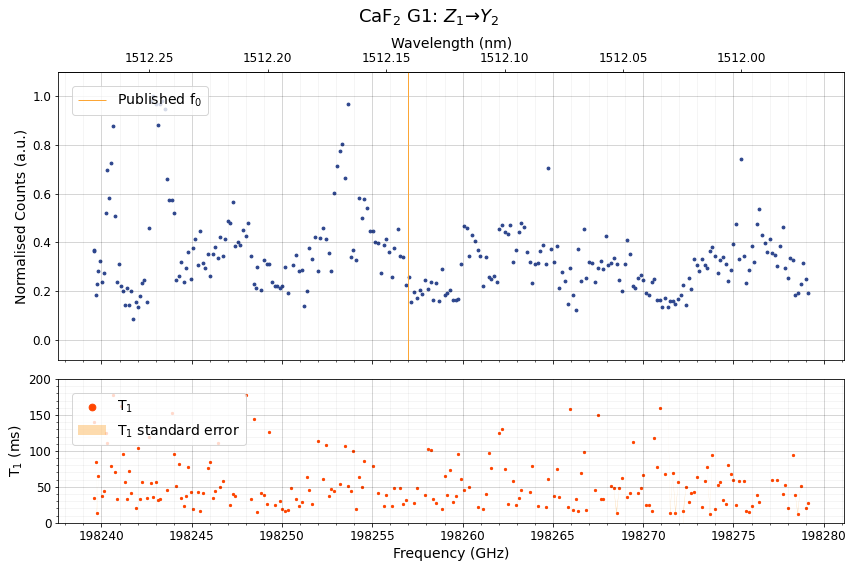

In [96]:
# G1 Z1_Y2 
freqs_G1_Z1Y2_0211 = G1_Z1Y2_0211['Frequency (MHz)']/1e3
cps_G1_Z1Y2_0211 = G1_Z1Y2_0211['Counts per second']
site = lines['G1_Z1Y2']
fits = lorentzians_0211['1512.018']

plot_double_spectrum(freqs_G1_Z1Y2_0211, cps_G1_Z1Y2_0211, life_G1_Z1Y2_0211['Fitted T1 (ms)'], life_G1_Z1Y2_0211['T1 error (ms)'], 
                    y0Ticks = [100, 0.5], y1Ticks = [50, 10], y0lims = None, y1lims = [0, 200],                 
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
                    norm = True, fits = None, save = True, savePath = savePlotPath_0211)

# plot_multi_spectrum(freqs_G1_Z1Y2_0211, cps_G1_Z1Y2_0211, life_G1_Z1Y2_0211['Fitted T1 (ms)'], life_G1_Z1Y2_0211['T1 error (ms)'], 
#                     y0Ticks = [100, 0.5], y1Ticks = [100, 5], y2Ticks = [100, 5],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = [-50, 800],
#                     norm = True, fits = None, save = True, savePath = savePlotPath_0211)

# plot_single_spectrum(freqs_G1_Z1Y2_0211, cps_G1_Z1Y2_0211, 
#                      cols, figsize = [12, 6], site = site, timeLimit = 0.0245, ylims = [-50, 700],
#                      lines = True, norm = False, fits = None,
#                      save = False, savePath = savePlotPath_0211, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_5108\3152481486.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


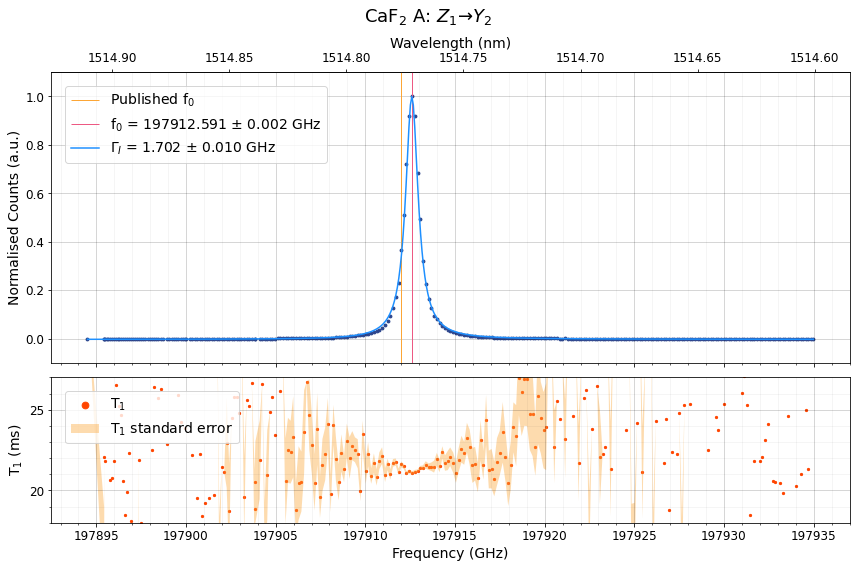

In [84]:
# A Z1_Y2 
freqs_A_Z1Y2_0211 = A_Z1Y2_0211['Frequency (MHz)']/1e3
cps_A_Z1Y2_0211 = A_Z1Y2_0211['Counts per second']
site = lines['A_Z1Y2']
fits = lorentzians_0211['1514.648']

plot_double_spectrum(freqs_A_Z1Y2_0211, cps_A_Z1Y2_0211, life_A_Z1Y2_0211['Fitted T1 (ms)'], life_A_Z1Y2_0211['T1 error (ms)'],
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y0lims = None, y1lims = [18, 27],                  
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
                    norm = True, fits = fits, save = True, savePath = savePlotPath_0211)

# plot_multi_spectrum(freqs_A_Z1Y2_0211, cps_A_Z1Y2_0211, life_A_Z1Y2_0211['Fitted T1 (ms)'], life_A_Z1Y2_0211['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 2], y2Ticks = [5, 2],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = None,
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_0211)

# plot_single_spectrum(freqs_A_Z1Y2_0211, cps_A_Z1Y2_0211, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = fits,
#                      save = True, savePath = savePlotPath_0211, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_5108\1377788946.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


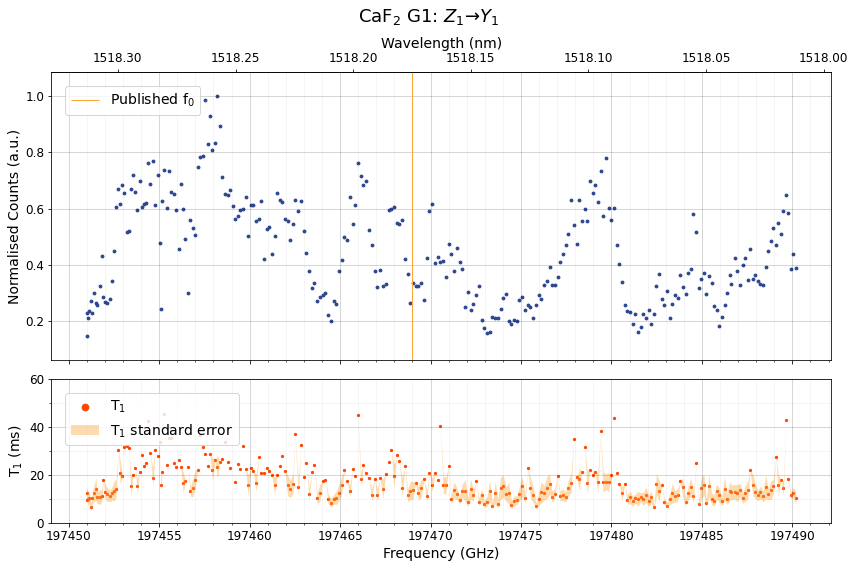

In [99]:
# G1 Z1_Y1
freqs_G1_Z1Y1_0211 = G1_Z1Y1_0211['Frequency (MHz)']/1e3
cps_G1_Z1Y1_0211 = G1_Z1Y1_0211['Counts per second']
site = lines['G1_Z1Y1']
fits = lorentzians_0211['1518.058']

plot_double_spectrum(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, 
                     life_G1_Z1Y1_0211['Fitted T1 (ms)'], life_G1_Z1Y1_0211['T1 error (ms)'], 
                    y0Ticks = [0.2, 0.1], y1Ticks = [20, 10], y0lims = [-50, 800], y1lims = [0, 60],                    
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
                    norm = True, fits = None, save = True, savePath = savePlotPath_0211)

# plot_multi_spectrum(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, life_G1_Z1Y1_0211['Fitted T1 (ms)'], life_G1_Z1Y1_0211['T1 error (ms)'], 
#                     y0Ticks = [0.2, 0.1], y1Ticks = [10, 5], y2Ticks = [10, 5],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = [-50, 800],
#                     norm = True, fits = None, save = True, savePath = savePlotPath_0211)

# plot_single_spectrum(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, cols, figsize = [12, 5], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = None,
#                      save = True, savePath = savePlotPath_0211, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_5108\1377788946.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


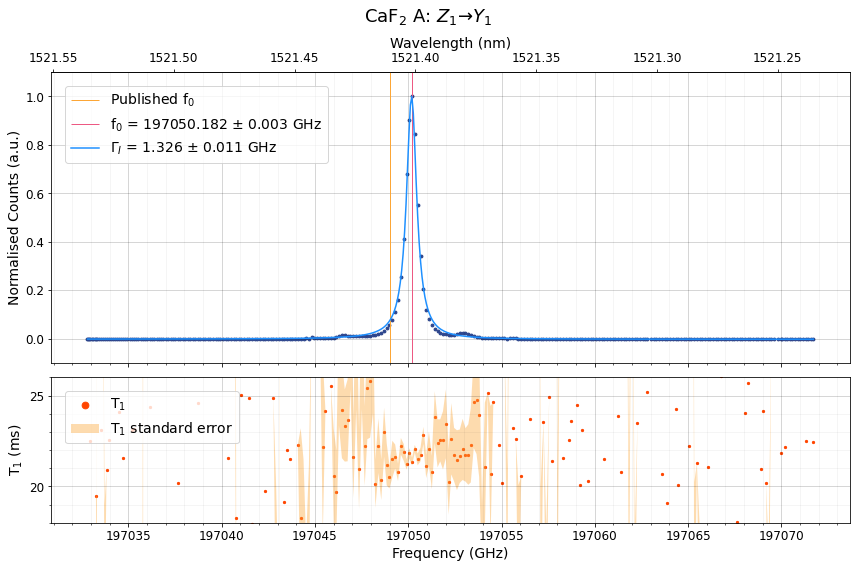

In [103]:
# A Z1_Y1 
freqs_A_Z1Y1_0211 = A_Z1Y1_0211['Frequency (MHz)']/1e3
cps_A_Z1Y1_0211 = A_Z1Y1_0211['Counts per second']
site = lines['A_Z1Y1']
fits = lorentzians_0211['1521.281']

plot_double_spectrum(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, life_A_Z1Y1_0211['Fitted T1 (ms)'], life_A_Z1Y1_0211['T1 error (ms)'],
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y0lims = None, y1lims = [18, 26],                 
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
                    norm = True, fits = fits, save = True, savePath = savePlotPath_0211)

# plot_multi_spectrum(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, life_A_Z1Y1_0211['Fitted T1 (ms)'], life_A_Z1Y1_0211['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 2], y2Ticks = [5, 2],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = None,
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_0211)

# plot_single_spectrum(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, cols, figsize = [12, 5], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = False, fits = fits,
#                      save = True, savePath = savePlotPath_0211, xLabel = 'Frequency (GHz)', plotDesc = None)

### 2025-10-18

In [ ]:
# Extract Data
saveDataPath_1018 = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2025-10-18'
savePlotPath_1018 = r'C:\Users\Mario\Documents\GitHub\Angela Honours\plots processed\2025-10-18'
spectraPath_1018 = os.path.join(fr'{saveDataPath_1018}\spectra')
spectraFiles_1018 = sorted(os.listdir(spectraPath_1018))
lifePath_1018 = os.path.join(fr'{saveDataPath_1018}\lifetimes')
lifeFiles_1018 = sorted(os.listdir(lifePath_1018))

lorentzians_1018 = pd.read_csv(os.path.join(saveDataPath_1018, 'lorentzian_fits.csv'), 
                        delimiter = ',', index_col = 0)

# C_Z1Y2_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[0]), delimiter = ',')
# C_Z1Y1_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[1]), delimiter = ',')
# B_Z1Y1_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[2]), delimiter = ',')
G1_Z1Y2_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[3]), delimiter = ',')
life_G1_Z1Y2_1018 = pd.read_csv(os.path.join(lifePath_1018, lifeFiles_1018[3]), delimiter = ',')
A_Z1Y2_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[4]), delimiter = ',')
life_A_Z1Y2_1018 = pd.read_csv(os.path.join(lifePath_1018, lifeFiles_1018[4]), delimiter = ',')
G1_Z1Y1_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[5]), delimiter = ',')
life_G1_Z1Y1_1018 = pd.read_csv(os.path.join(lifePath_1018, lifeFiles_1018[5]), delimiter = ',')
A_Z1Y1_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[6]), delimiter = ',')
life_A_Z1Y1_1018 = pd.read_csv(os.path.join(lifePath_1018, lifeFiles_1018[6]), delimiter = ',')

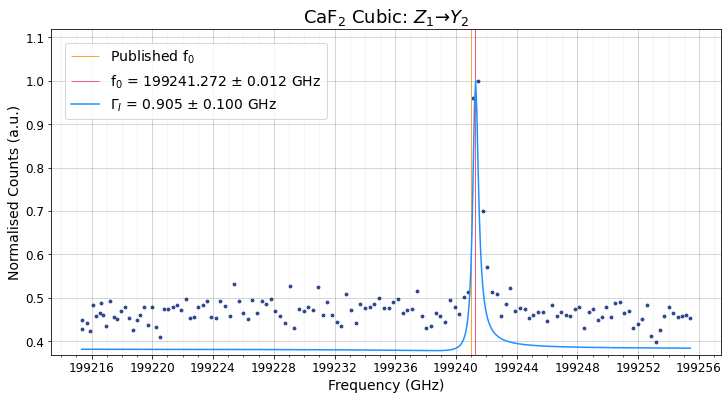

In [ ]:
# C Z1_Y2 
freqs = C_Z1Y2_1018['Frequency (MHz)']/1e3
cps = C_Z1Y2_1018['Counts per second']
site = lines['C_Z1Y2']
fits = lorentzians_1018['1504.59024']

plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
                     lines = True, norm = True, fits = fits,
                     save = True, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

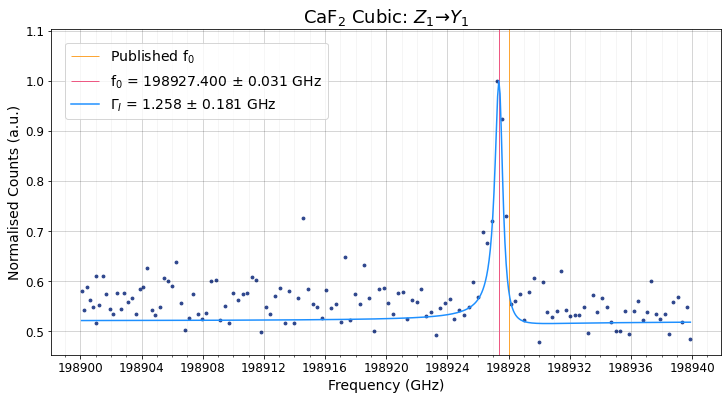

In [ ]:
# C Z1_Y1
freqs = C_Z1Y1_1018['Frequency (MHz)']/1e3
cps = C_Z1Y1_1018['Counts per second']
site = lines['C_Z1Y1']
fits = lorentzians_1018['1506.976']

plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
                     lines = True, norm = True, fits = fits,
                     save = True, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

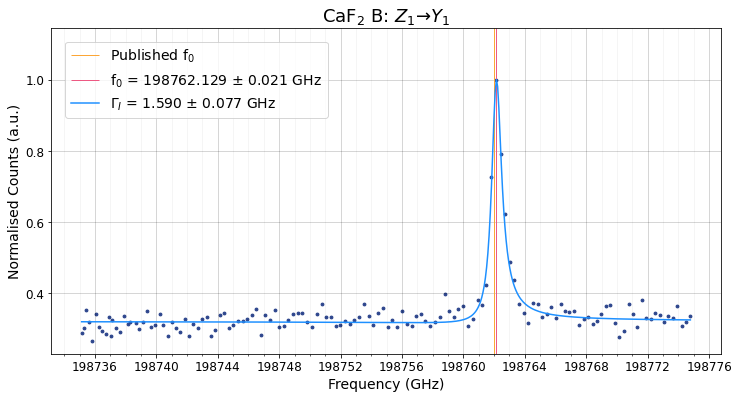

In [ ]:
# B Z1_Y1
freqs = B_Z1Y1_1018['Frequency (MHz)']/1e3
cps = B_Z1Y1_1018['Counts per second']
site = lines['B_Z1Y1']
fits = lorentzians_1018['1508.22566']

plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
                     lines = True, norm = True, fits = fits,
                     save = True, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\2340540691.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


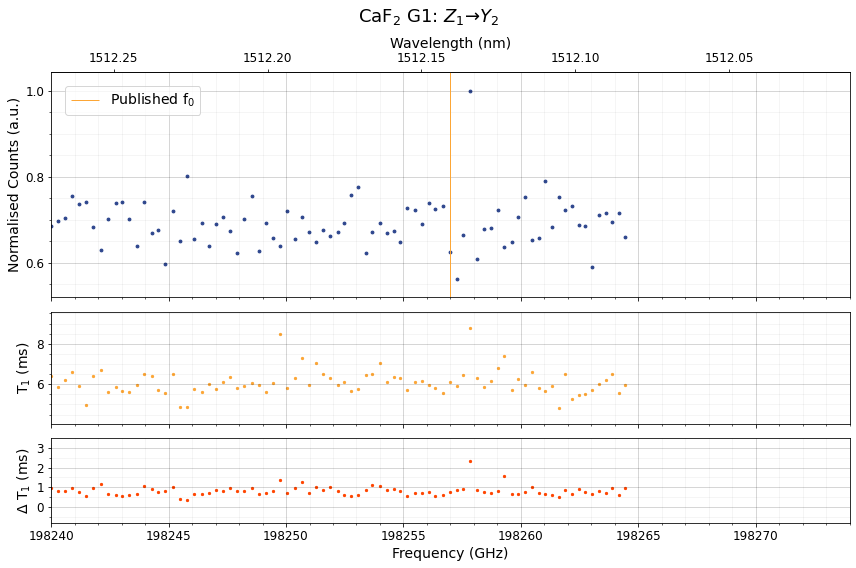

In [ ]:
# G1 Z1_Y2 
freqs_G1_Z1Y2_1018 = G1_Z1Y2_1018['Frequency (MHz)']/1e3
cps_G1_Z1Y2_1018 = G1_Z1Y2_1018['Counts per second']
# max_index = np.argmax(cps_G1_Z1Y2_1018)
# cps_G1_Z1Y2_1018 = np.delete(cps_G1_Z1Y2_1018, max_index)
site = lines['G1_Z1Y2']
fits_G1_Z1Y2_1018 = lorentzians_1018['1512.10873']

plot_multi_spectrum(freqs_G1_Z1Y2_1018, cps_G1_Z1Y2_1018, life_G1_Z1Y2_1018['Fitted T1 (ms)'], life_G1_Z1Y2_1018['T1 error (ms)'],
                    y0Ticks = [0.2, 0.05], y1Ticks = [2, 0.5], y2Ticks = [1, 0.5],
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
                    norm = True, fits = None, save = False, savePath = savePlotPath_1018)

# plot_single_spectrum(freqs_G1_Z1Y2_1018, cps_G1_Z1Y2_1018, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = None,
#                      save = False, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\1789887106.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


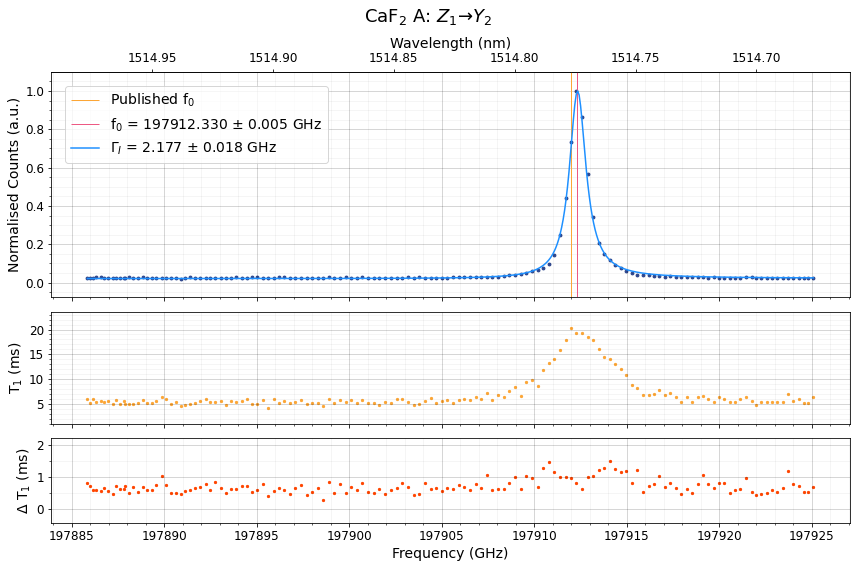

In [ ]:
# A Z1_Y2
freqs_A_Z1Y2_1018 = A_Z1Y2_1018['Frequency (MHz)']/1e3
cps_A_Z1Y2_1018 = A_Z1Y2_1018['Counts per second']
site = lines['A_Z1Y2']
fits = lorentzians_1018['1514.7']

plot_multi_spectrum(freqs_A_Z1Y2_1018, cps_A_Z1Y2_1018, life_A_Z1Y2_1018['Fitted T1 (ms)'], life_A_Z1Y2_1018['T1 error (ms)'],
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y2Ticks = [1, 0.5],                    
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
                    norm = True, fits = fits, save = True, savePath = savePlotPath_1018)

# plot_single_spectrum(freqs_A_Z1Y2_1018, cps_A_Z1Y2_1018, cols, figsize = [12, 5], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = False, fits = fits,
#                      save = True, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\1789887106.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


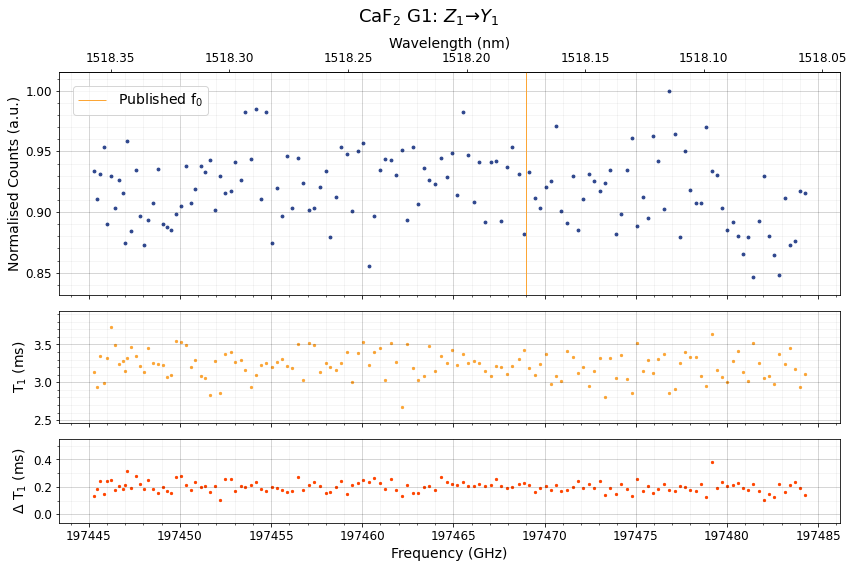

In [ ]:
# G1 Z1_Y1
freqs_G1_Z1Y1_1018 = G1_Z1Y1_1018['Frequency (MHz)']/1e3
cps_G1_Z1Y1_1018 = G1_Z1Y1_1018['Counts per second']
site = lines['G1_Z1Y1']
fits = lorentzians_1018['1518.08']

plot_multi_spectrum(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018, life_G1_Z1Y1_1018['Fitted T1 (ms)'], life_G1_Z1Y1_1018['T1 error (ms)'],
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
                    y0Ticks = [0.05, 0.01], y1Ticks = [0.5, 0.1], y2Ticks = [0.2, 0.1], 
                    norm = True, fits = None, save = True, savePath = savePlotPath_1018)

# plot_single_spectrum(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = None,
#                      save = True, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\1789887106.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


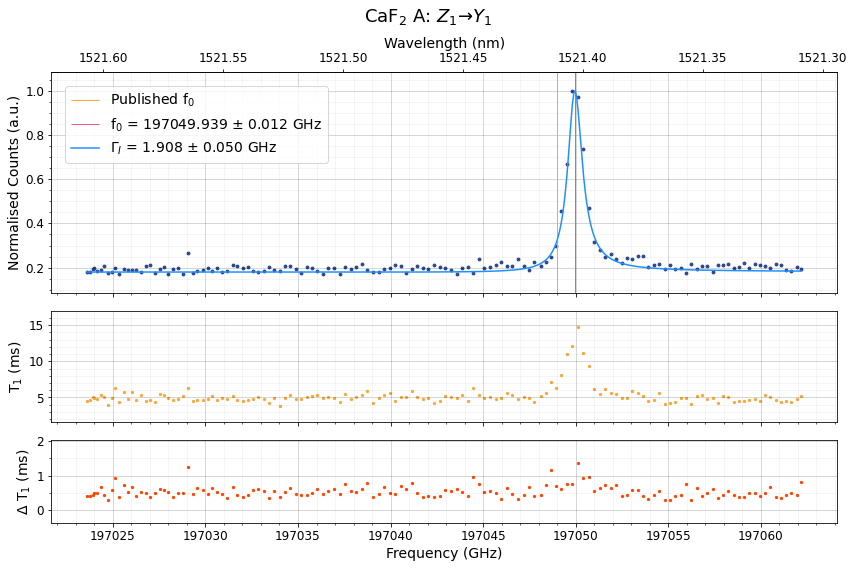

In [ ]:
# A Z1_Y1 
freqs_A_Z1Y1_1018 = A_Z1Y1_1018['Frequency (MHz)']/1e3
cps_A_Z1Y1_1018 = A_Z1Y1_1018['Counts per second']
site = lines['A_Z1Y1']
fits = lorentzians_1018['1521.33084']

plot_multi_spectrum(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018, life_A_Z1Y1_1018['Fitted T1 (ms)'], life_A_Z1Y1_1018['T1 error (ms)'],
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y2Ticks = [1, 0.5], 
                    norm = True, fits = fits, save = True, savePath = savePlotPath_1018)

# plot_single_spectrum(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018, cols, figsize = [12, 5], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = False, fits = fits,
#                      save = True, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

### 2025-10-25

In [ ]:
# Extract Data
saveDataPath_1025 = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2025-10-25'
savePlotPath_1025 = r'C:\Users\Mario\Documents\GitHub\Angela Honours\plots processed\2025-10-25'
spectraPath_1025 = os.path.join(fr'{saveDataPath_1025}\spectra')
spectraFiles_1025 = sorted(os.listdir(spectraPath_1025))
lifePath_1025 = os.path.join(fr'{saveDataPath_1025}\lifetimes')
lifeFiles_1025 = sorted(os.listdir(lifePath_1025))

lorentzians_1025 = pd.read_csv(os.path.join(saveDataPath_1025, 'lorentzian_fits.csv'), 
                        delimiter = ',', index_col = 0)

# C_Z1Y2_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[0]), delimiter = ',')
# C_Z1Y1_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[1]), delimiter = ',')
# B_Z1Y1_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[2]), delimiter = ',')
G1_Z1Y2_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[3]), delimiter = ',')
life_G1_Z1Y2_1025 = pd.read_csv(os.path.join(lifePath_1025, lifeFiles_1025[3]), delimiter = ',')
A_Z1Y2_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[4]), delimiter = ',')
life_A_Z1Y2_1025 = pd.read_csv(os.path.join(lifePath_1025, lifeFiles_1025[4]), delimiter = ',')
G1_Z1Y1_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[5]), delimiter = ',')
life_G1_Z1Y1_1025 = pd.read_csv(os.path.join(lifePath_1025, lifeFiles_1025[5]), delimiter = ',')
A_Z1Y1_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[6]), delimiter = ',')
life_A_Z1Y1_1025 = pd.read_csv(os.path.join(lifePath_1025, lifeFiles_1025[6]), delimiter = ',')

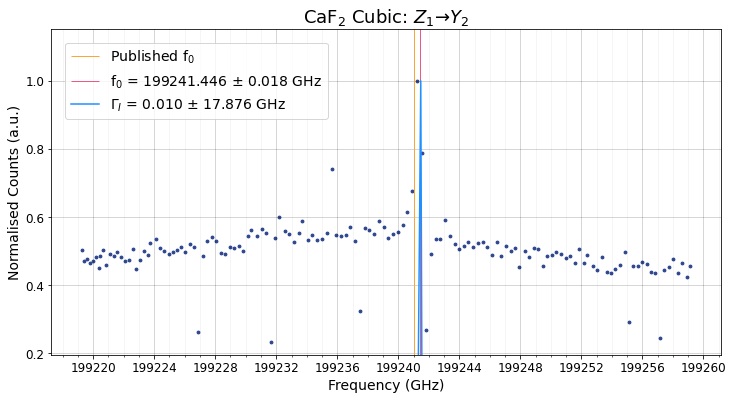

In [ ]:
# C Z1_Y2 
freqs = C_Z1Y2_1025['Frequency (MHz)']/1e3
cps = C_Z1Y2_1025['Counts per second']
site = lines['C_Z1Y2']
fits = fits_1025['1504.59024']

plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
                     lines = True, norm = True, fits = fits,
                     save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

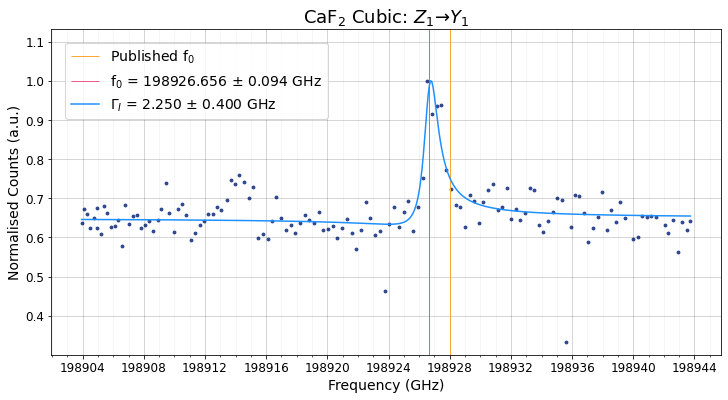

In [ ]:
# C Z1_Y1
freqs = C_Z1Y1_1025['Frequency (MHz)']/1e3
cps = C_Z1Y1_1025['Counts per second']
site = lines['C_Z1Y1']
fits = fits_1025['1506.976']

plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
                     lines = True, norm = True, fits = fits,
                     save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

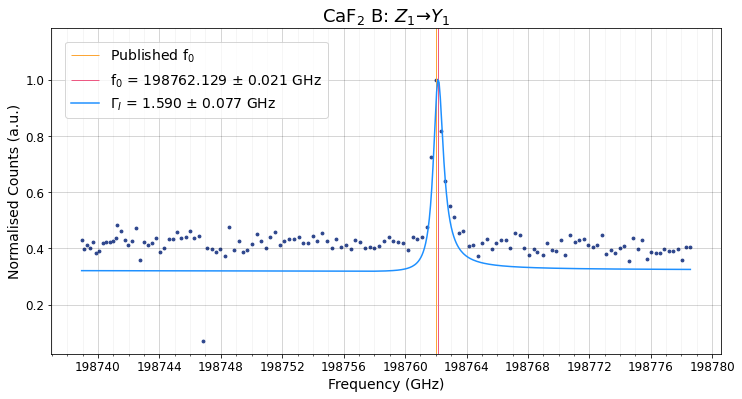

In [ ]:
# B Z1_Y1
freqs = B_Z1Y1_1025['Frequency (MHz)']/1e3
cps = B_Z1Y1_1025['Counts per second']
site = lines['B_Z1Y1']
fits = fits_1018['1508.22566']

plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
                     lines = True, norm = True, fits = fits,
                     save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\767777754.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


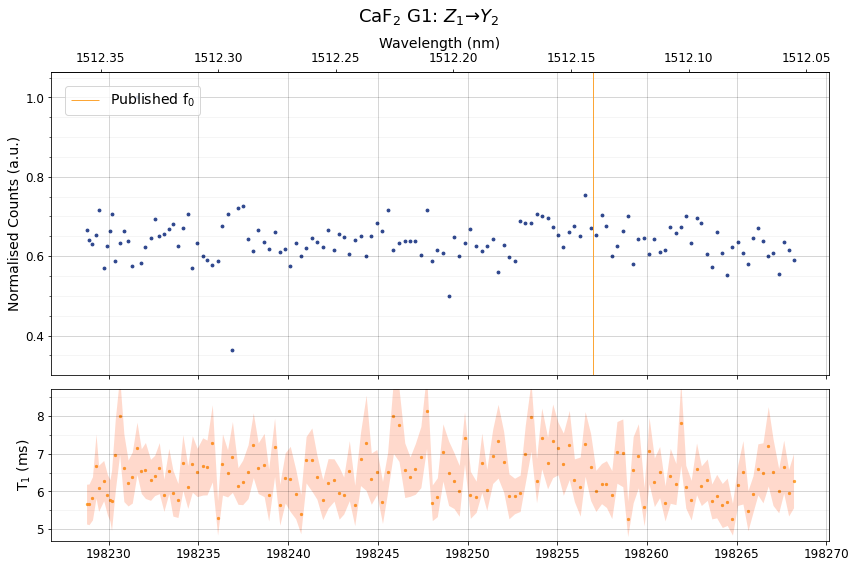

In [ ]:
# G1 Z1_Y2 
freqs_G1_Z1Y2_1025 = G1_Z1Y2_1025['Frequency (MHz)']/1e3
cps_G1_Z1Y2_1025 = G1_Z1Y2_1025['Counts per second']
site = lines['G1_Z1Y2']
fits_G1_Z1Y2_1025 = lorentzians_1025['1512.10873']

plot_double_spectrum(freqs_G1_Z1Y2_1025, cps_G1_Z1Y2_1025, life_G1_Z1Y2_1025['Fitted T1 (ms)'], life_G1_Z1Y2_1025['T1 error (ms)'],
                    y0Ticks = [0.2, 0.05], y1Ticks = [1, 0.5], ylims = [0, 1e6],
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
                    norm = True, fits = None, save = True, savePath = savePlotPath_1025)

# plot_multi_spectrum(freqs_G1_Z1Y2_1025, cps_G1_Z1Y2_1025, life_G1_Z1Y2_1025['Fitted T1 (ms)'], life_G1_Z1Y2_1025['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [2, 0.5], y2Ticks = [1, 0.5],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
#                     norm = True, fits = None, save = True, savePath = savePlotPath_1025)

# plot_single_spectrum(freqs_G1_Z1Y2_1025, cps_G1_Z1Y2_1025, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = None,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\1677493240.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


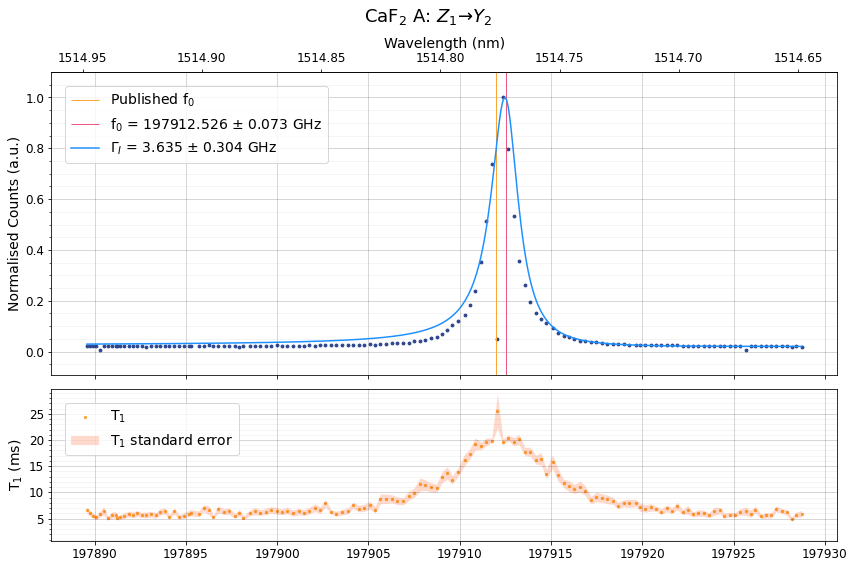

In [ ]:
# A Z1_Y2 
freqs_A_Z1Y2_1025 = A_Z1Y2_1025['Frequency (MHz)']/1e3
cps_A_Z1Y2_1025 = A_Z1Y2_1025['Counts per second']
site = lines['A_Z1Y2']
fits_G1_Z1Y2_1025 = lorentzians_1025['1514.7']

plot_double_spectrum(freqs_A_Z1Y2_1025, cps_A_Z1Y2_1025, life_A_Z1Y2_1025['Fitted T1 (ms)'], life_A_Z1Y2_1025['T1 error (ms)'],
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], ylims = [0, 1e6],
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
                    norm = True, fits = fits_G1_Z1Y2_1025, save = True, savePath = savePlotPath_1025)

# plot_multi_spectrum(freqs_A_Z1Y2_1025, cps_A_Z1Y2_1025, life_A_Z1Y2_1025['Fitted T1 (ms)'], life_A_Z1Y2_1025['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 2], y2Ticks = [2, 1],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = [0, 1e6],
#                     norm = True, fits = fits_G1_Z1Y2_1025, save = True, savePath = savePlotPath_1025)

# plot_single_spectrum(freqs_A_Z1Y2_1025, cps_A_Z1Y2_1025, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = fits_G1_Z1Y2_1025,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\2340540691.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


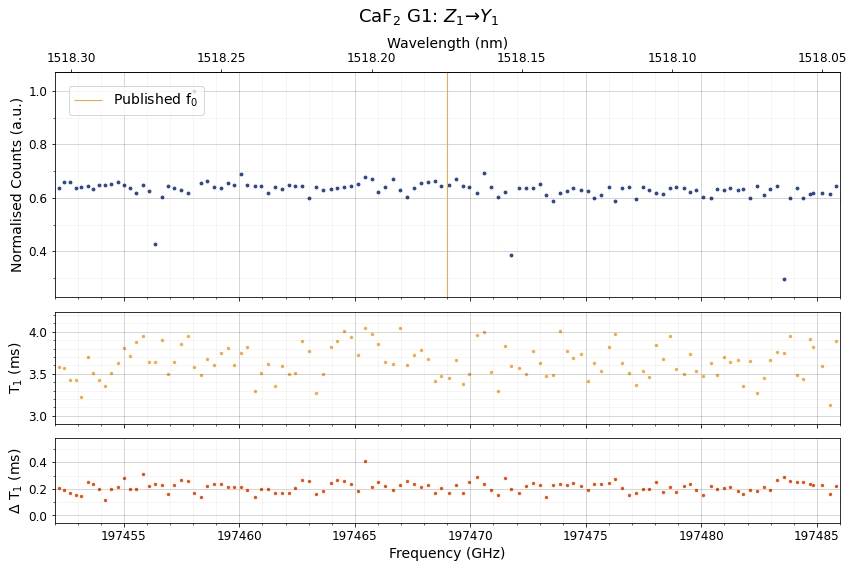

In [ ]:
# G1 Z1_Y1
freqs_G1_Z1Y1_1025 = G1_Z1Y1_1025['Frequency (MHz)']/1e3
cps_G1_Z1Y1_1025 = G1_Z1Y1_1025['Counts per second']
site = lines['G1_Z1Y1']
fits_G1_Z1Y2_1025 = lorentzians_1025['1518.08']

plot_multi_spectrum(freqs_G1_Z1Y1_1025, cps_G1_Z1Y1_1025, life_G1_Z1Y1_1025['Fitted T1 (ms)'], life_G1_Z1Y1_1025['T1 error (ms)'],
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
                    y0Ticks = [0.2, 0.1], y1Ticks = [0.5, 0.1], y2Ticks = [0.2, 0.1], 
                    norm = True, fits = None, save = True, savePath = savePlotPath_1025)

# plot_single_spectrum(freqs_G1_Z1Y1_1025, cps_G1_Z1Y1_1025, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = None,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\2340540691.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


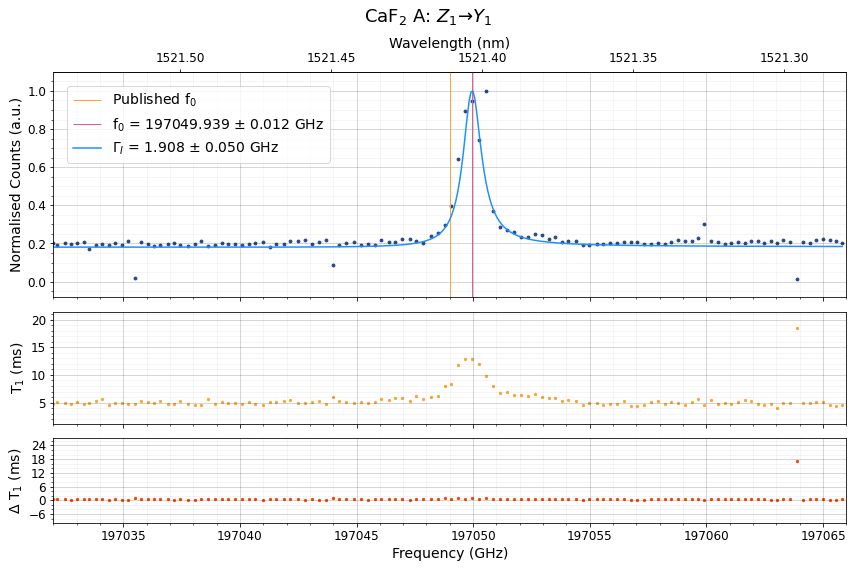

In [ ]:
# A Z1_Y1
freqs_A_Z1Y1_1025 = A_Z1Y1_1025['Frequency (MHz)']/1e3
cps_A_Z1Y1_1025 = A_Z1Y1_1025['Counts per second']
site = lines['A_Z1Y1']
fits_A_Z1Y1_1025 = lorentzians_1025['1521.33084']

plot_multi_spectrum(freqs_A_Z1Y1_1025, cps_A_Z1Y1_1025, life_A_Z1Y1_1025['Fitted T1 (ms)'], life_A_Z1Y1_1025['T1 error (ms)'],
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y2Ticks = [6, 2], 
                    norm = True, fits = fits, save = True, savePath = savePlotPath_1025)

# plot_single_spectrum(freqs_A_Z1Y1_1025, cps_A_Z1Y1_1025, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = fits_A_Z1Y1_1025,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

## Position Comparison

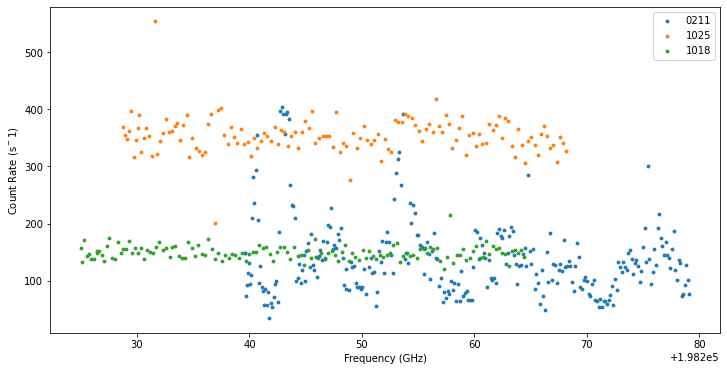

In [ ]:
# G1 Z1-Y2
plt.figure(figsize = (12, 6))
plt.scatter(freqs_G1_Z1Y2_0211, cps_G1_Z1Y2_0211, s = 8, label = '0211')
plt.scatter(freqs_G1_Z1Y2_1025, cps_G1_Z1Y2_1025, s = 8, label = '1025')
plt.scatter(freqs_G1_Z1Y2_1018, cps_G1_Z1Y2_1018, s = 8, label = '1018')
plt.xlabel('Frequency (GHz)')
plt.ylabel(fr'Count Rate (s$^{-1}$)')

plt.legend()
plt.show()

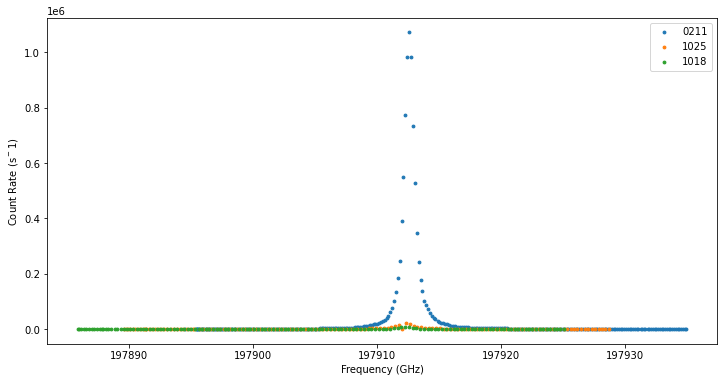

In [ ]:
# A Z1-Y2
%matplotlib inline
plt.figure(figsize = (12, 6))
plt.scatter(freqs_A_Z1Y2_0211, cps_A_Z1Y2_0211, s = 8, label = '0211')
plt.scatter(freqs_A_Z1Y2_1025, cps_A_Z1Y2_1025, s = 8, label = '1025')
plt.scatter(freqs_A_Z1Y2_1018, cps_A_Z1Y2_1018, s = 8, label = '1018')
plt.xlabel('Frequency (GHz)')
plt.ylabel(fr'Count Rate (s$^{-1}$)')
plt.legend()
plt.show()

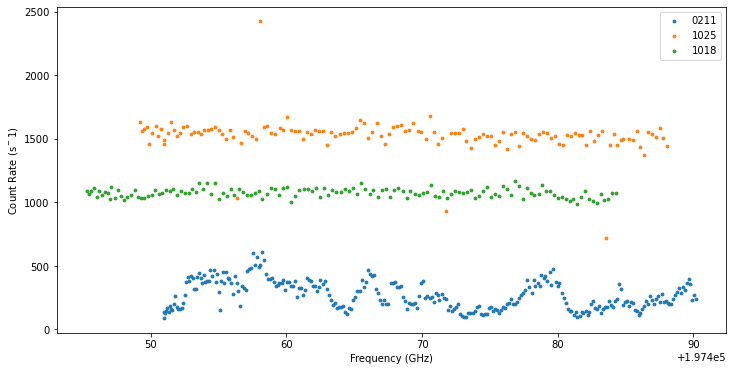

In [ ]:
# G1 Z1-Y2
plt.figure(figsize = (12, 6))
plt.scatter(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, s = 8, label = '0211')
plt.scatter(freqs_G1_Z1Y1_1025, cps_G1_Z1Y1_1025, s = 8, label = '1025')
plt.scatter(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018, s = 8, label = '1018')
plt.xlabel('Frequency (GHz)')
plt.ylabel(fr'Count Rate (s$^{-1}$)')
plt.legend()
plt.show()

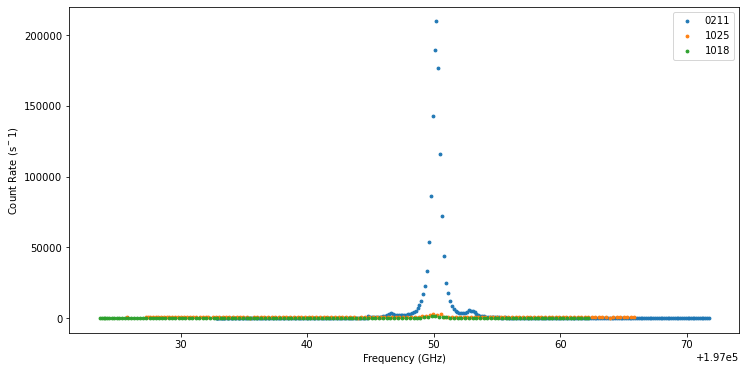

In [ ]:
# A Z1-Y1
%matplotlib inline
plt.figure(figsize = (12, 6))
plt.scatter(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, s = 8, label = '0211')
plt.scatter(freqs_A_Z1Y1_1025, cps_A_Z1Y1_1025, s = 8, label = '1025')
plt.scatter(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018, s = 8, label = '1018')
plt.xlabel('Frequency (GHz)')
plt.ylabel(fr'Count Rate (s$^{-1}$)')
plt.legend()
plt.show()

## Motor/Stitched Scans

In [ ]:
lines = {'C_Z1Y2': [fr'Cubic: $Z_1 \to Y_2$', 199.241e6], # Cubic Z1-Y2
        'C_Z1Y1': [fr'Cubic: $Z_1 \to Y_1$', 198.928e6], # Cubic Z1-Y1  
        'B_Z1Y1': [fr'B: $Z_1 \to Y_1$', 198.762e6], # B Z1-Y1
        'G1_Z1Y2': [fr'G1: $Z_1 \to Y_2$', 198.257e6], # G1 Z1-Y2
        'A_Z1Y2': [fr'A: $Z_1 \to Y_2$', 197.912e6], # A Z1-Y2
        'G1_Z1Y1': [fr'G1: $Z_1 \to Y_1$',197.469e6], # G1 Z1-Y1
        'A_Z1Y1': [fr'A: $Z_1 \to Y_1$', 197.049e6]} # A Z1-Y1  

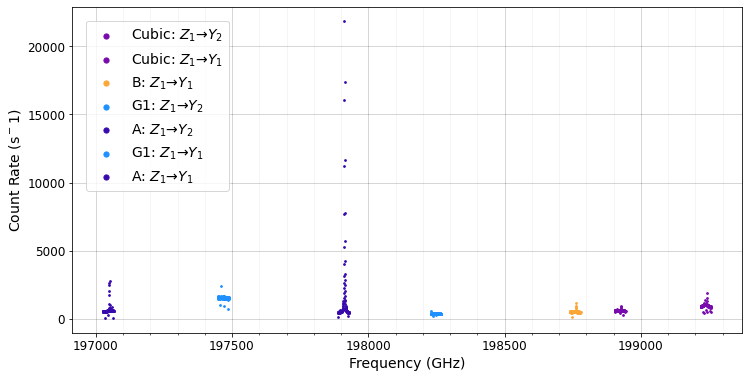

In [ ]:
plt.figure(figsize = (12, 6))
cols_stitched = ['#380aad', 'dodgerblue', '#FCA636FF','#790aad']
ms = 3

plt.scatter(C_Z1Y2_1025['Frequency (MHz)']/1e3, C_Z1Y2_1025['Counts per second'],
            color = cols_stitched[3], s = ms, label = fr"{lines['C_Z1Y2'][0]}")
plt.scatter(C_Z1Y1_1025['Frequency (MHz)']/1e3, C_Z1Y1_1025['Counts per second'],
            color = cols_stitched[3], s = ms, label = fr"{lines['C_Z1Y1'][0]}")
plt.scatter(B_Z1Y1_1025['Frequency (MHz)']/1e3, B_Z1Y1_1025['Counts per second'],
            color = cols_stitched[2], s = ms, label = fr"{lines['B_Z1Y1'][0]}")
plt.scatter(G1_Z1Y2_1025['Frequency (MHz)']/1e3, G1_Z1Y2_1025['Counts per second'],
            color = cols_stitched[1], s = ms, label = fr"{lines['G1_Z1Y2'][0]}")
plt.scatter(A_Z1Y2_1025['Frequency (MHz)']/1e3, A_Z1Y2_1025['Counts per second'],
            color = cols_stitched[0], s = ms, label = fr"{lines['A_Z1Y2'][0]}")
plt.scatter(G1_Z1Y1_1025['Frequency (MHz)']/1e3, G1_Z1Y1_1025['Counts per second'],
            color = cols_stitched[1], s = ms, label = fr"{lines['G1_Z1Y1'][0]}")
plt.scatter(A_Z1Y1_1025['Frequency (MHz)']/1e3, A_Z1Y1_1025['Counts per second'],
            color = cols_stitched[0], s = ms, label = fr"{lines['A_Z1Y1'][0]}")

ax = plt.gca()
plt.xlabel('Frequency (GHz)', fontsize = 14)
plt.ylabel(fr'Count Rate (s$^{-1}$)', fontsize = 14)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(400))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.tick_params(axis = 'both', labelsize=12)
plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
plt.legend(fontsize = 14, markerscale = 3, borderaxespad = 1, loc = 'upper left')
plt.show()

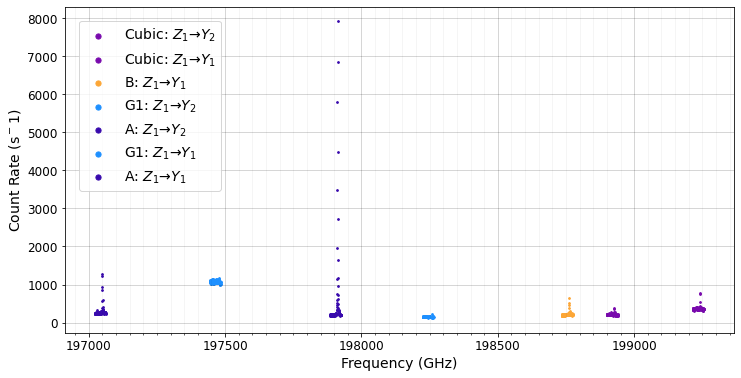

In [ ]:
plt.figure(figsize = (12, 6))
cols_stitched = ['#380aad', 'dodgerblue', '#FCA636FF','#790aad']
ms = 3

plt.scatter(C_Z1Y2_1018['Frequency (MHz)']/1e3, C_Z1Y2_1018['Counts per second'],
            color = cols_stitched[3], s = ms, label = fr"{lines['C_Z1Y2'][0]}")
plt.scatter(C_Z1Y1_1018['Frequency (MHz)']/1e3, C_Z1Y1_1018['Counts per second'],
            color = cols_stitched[3], s = ms, label = fr"{lines['C_Z1Y1'][0]}")
plt.scatter(B_Z1Y1_1018['Frequency (MHz)']/1e3, B_Z1Y1_1018['Counts per second'],
            color = cols_stitched[2], s = ms, label = fr"{lines['B_Z1Y1'][0]}")
plt.scatter(G1_Z1Y2_1018['Frequency (MHz)']/1e3, G1_Z1Y2_1018['Counts per second'],
            color = cols_stitched[1], s = ms, label = fr"{lines['G1_Z1Y2'][0]}")
plt.scatter(A_Z1Y2_1018['Frequency (MHz)']/1e3, A_Z1Y2_1018['Counts per second'],
            color = cols_stitched[0], s = ms, label = fr"{lines['A_Z1Y2'][0]}")
plt.scatter(G1_Z1Y1_1018['Frequency (MHz)']/1e3, G1_Z1Y1_1018['Counts per second'],
            color = cols_stitched[1], s = ms, label = fr"{lines['G1_Z1Y1'][0]}")
plt.scatter(A_Z1Y1_1018['Frequency (MHz)']/1e3, A_Z1Y1_1018['Counts per second'],
            color = cols_stitched[0], s = ms, label = fr"{lines['A_Z1Y1'][0]}")

ax = plt.gca()
plt.xlabel('Frequency (GHz)', fontsize = 14)
plt.ylabel(fr'Count Rate (s$^{-1}$)', fontsize = 14)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(400))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.tick_params(axis = 'both', labelsize=12)
plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
plt.legend(fontsize = 14, markerscale = 3, borderaxespad = 1, loc = 'upper left')
plt.show()



In [ ]:
plt.figure(figsize = (12, 6))
cols_stitched = ['#380aad', 'dodgerblue', '#FCA636FF','#790aad']
ms = 3

plt.scatter(C_Z1Y2_1018['Frequency (MHz)']/1e3, C_Z1Y2_1018['Counts per second'],
            color = cols_stitched[3], s = ms, label = fr"{lines['C_Z1Y2'][0]}")
plt.scatter(C_Z1Y1_1018['Frequency (MHz)']/1e3, C_Z1Y1_1018['Counts per second'],
            color = cols_stitched[3], s = ms, label = fr"{lines['C_Z1Y1'][0]}")
plt.scatter(B_Z1Y1_1018['Frequency (MHz)']/1e3, B_Z1Y1_1018['Counts per second'],
            color = cols_stitched[2], s = ms, label = fr"{lines['B_Z1Y1'][0]}")
plt.scatter(G1_Z1Y2_1018['Frequency (MHz)']/1e3, G1_Z1Y2_1018['Counts per second'],
            color = cols_stitched[1], s = ms, label = fr"{lines['G1_Z1Y2'][0]}")
plt.scatter(A_Z1Y2_1018['Frequency (MHz)']/1e3, A_Z1Y2_1018['Counts per second'],
            color = cols_stitched[0], s = ms, label = fr"{lines['A_Z1Y2'][0]}")
plt.scatter(G1_Z1Y1_1018['Frequency (MHz)']/1e3, G1_Z1Y1_1018['Counts per second'],
            color = cols_stitched[1], s = ms, label = fr"{lines['G1_Z1Y1'][0]}")
plt.scatter(A_Z1Y1_1018['Frequency (MHz)']/1e3, A_Z1Y1_1018['Counts per second'],
            color = cols_stitched[0], s = ms, label = fr"{lines['A_Z1Y1'][0]}")

ax = plt.gca()
plt.xlabel('Frequency (GHz)', fontsize = 14)
plt.ylabel(fr'Count Rate (s$^{-1}$)', fontsize = 14)
ax.xaxis.set_major_locator(ticker.MultipleLocator(400))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.tick_params(axis = 'both', labelsize=12)
plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
plt.legend(fontsize = 14, markerscale = 3, borderaxespad = 1, loc = 'upper left')
plt.show()

In [ ]:
plt.figure(figsize = (12, 6))

plt.scatter(G1_Z1Y2_0211['Frequency (MHz)']/1e3, G1_Z1Y2_0211['Counts per second'])
plt.scatter(A_Z1Y2_0211['Frequency (MHz)']/1e3, A_Z1Y2_0211['Counts per second'])
plt.scatter(G1_Z1Y1_0211['Frequency (MHz)']/1e3, G1_Z1Y1_0211['Counts per second'])
plt.scatter(A_Z1Y1_0211['Frequency (MHz)']/1e3, A_Z1Y1_0211['Counts per second'])

plt.show()

# CaF Post-Anneal

In [11]:
# Extract Data
saveDataPath_0429 = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-04-29'
savePlotPath_0429 = r'C:\Users\Mario\Documents\GitHub\Angela Honours\plots processed\2026-04-29'

spectraPath_0429 = os.path.join(fr'{saveDataPath_0429}\spectra')
spectraFiles_0429 = sorted(os.listdir(spectraPath_0429))
lifePath_0429 = os.path.join(fr'{saveDataPath_0429}\lifetimes')
lifeFiles_0429 = sorted(os.listdir(lifePath_0429))

lorentzians_0429 = pd.read_csv(os.path.join(saveDataPath_0429, 'lorentzian_fits.csv'), 
                        delimiter = ',', index_col = 0)

G1_Z1Y1_0429 = pd.read_csv(os.path.join(spectraPath_0429, spectraFiles_0429[0]), delimiter = ',')
life_G1_Z1Y1_0429 = pd.read_csv(os.path.join(lifePath_0429, lifeFiles_0429[0]), delimiter = ',')
A_Z1Y1_0429 = pd.read_csv(os.path.join(spectraPath_0429, spectraFiles_0429[1]), delimiter = ',')
life_A_Z1Y1_0429 = pd.read_csv(os.path.join(lifePath_0429, lifeFiles_0429[1]), delimiter = ',')

C:\Users\Mario\AppData\Local\Temp\ipykernel_5108\1377788946.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


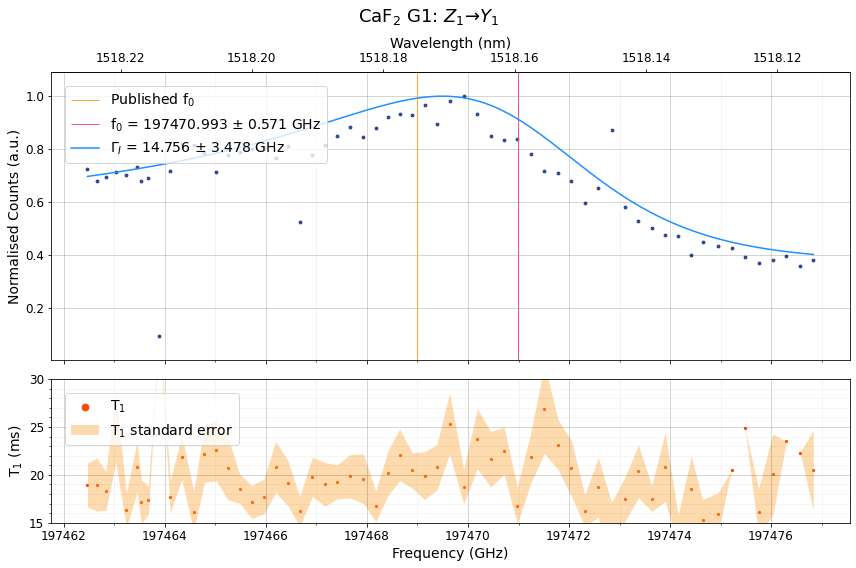

In [104]:
# G1 Z1-Y1
freqs_G1_Z1Y1_0429 = G1_Z1Y1_0429['Frequency (MHz)']/1e3
cps_G1_Z1Y1_0429 = G1_Z1Y1_0429['Counts per second']
site = lines['G1_Z1Y1']
fits = lorentzians_0429['1518.05800']

plot_double_spectrum(freqs_G1_Z1Y1_0429, cps_G1_Z1Y1_0429, life_G1_Z1Y1_0429['Fitted T1 (ms)'], life_G1_Z1Y1_0429['T1 error (ms)'],
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y0lims = None, y1lims = [15, 30],                  
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
                    norm = True, fits = fits, save = True, savePath = savePlotPath_0429)

C:\Users\Mario\AppData\Local\Temp\ipykernel_5108\3424184958.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


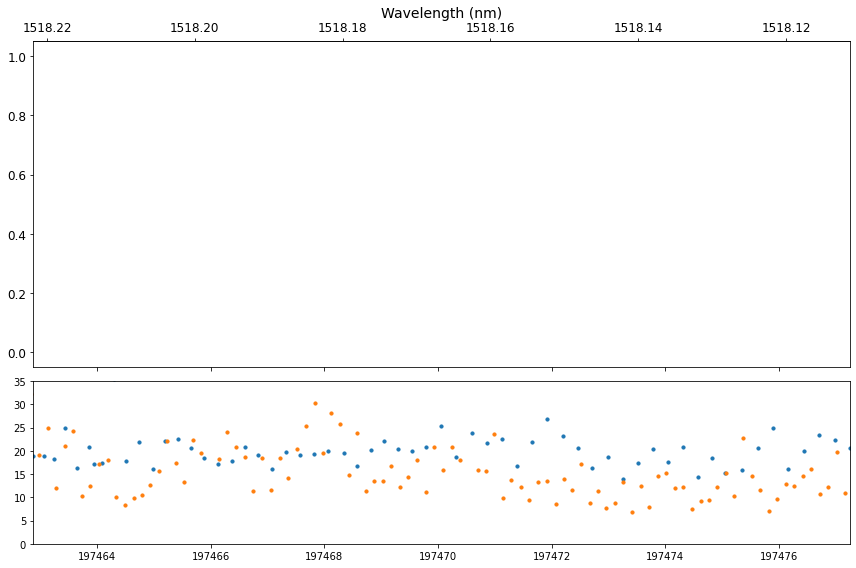

In [71]:
c = 299792458  # m/s

def freq_to_wavelength(f_GHz):
    return c / (f_GHz * 1e9) * 1e9  # → nm

def wavelength_to_freq(l_nm):
    return c / (l_nm * 1e-9) / 1e9  # → GHz

fig, (ax0, ax1) = plt.subplots(
    2, 1,
    figsize = (12, 8),
    gridspec_kw = {'height_ratios': [2, 1]},
    sharex = True
)

# cpsRange = max(cps_G1_Z1Y1_0429) - min(cps_G1_Z1Y1_0429)
# ax0.scatter(freqs_G1_Z1Y1_0429 + 0.41, cps_G1_Z1Y1_0429/max(cps_G1_Z1Y1_0429), 
#             c = cols[0], s = 8)
ax0.scatter(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211/max(cps_A_Z1Y1_0211),
            c = cols[1], s = 12)
ax0.tick_params(axis = 'both', labelsize = 12) 
ax0.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
# ax0.set_ylim([0, 1.1])
ax0.set_xlim([min(freqs_G1_Z1Y1_0429 + 0.410), max(freqs_G1_Z1Y1_0429 + 0.410)])
secax = ax0.secondary_xaxis(
    'top',
    functions=(freq_to_wavelength, wavelength_to_freq)
)
secax.set_xlabel('Wavelength (nm)', fontsize = 14)
secax.tick_params(axis = 'x', labelsize = 12)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 

ax1.scatter(freqs_G1_Z1Y1_0429 + 0.41, life_G1_Z1Y1_0429['Fitted T1 (ms)'],
            s = 10)
ax1.scatter(freqs_G1_Z1Y1_0211, life_G1_Z1Y1_0211['Fitted T1 (ms)'],
            s = 10)
ax1.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('gah.png', transparent = True)
plt.show()

C:\Users\Mario\AppData\Local\Temp\ipykernel_5108\1377788946.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


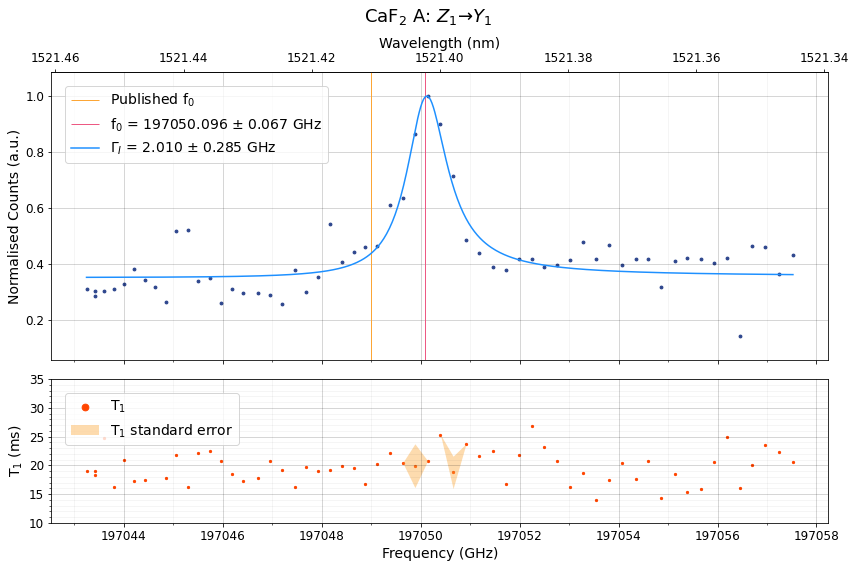

In [109]:
# A Z1-Y1
freqs_A_Z1Y1_0429 = A_Z1Y1_0429['Frequency (MHz)']/1e3
cps_A_Z1Y1_0429 = A_Z1Y1_0429['Counts per second']
site = lines['A_Z1Y1']
fits = lorentzians_0429['1521.28800']

plot_double_spectrum(freqs_A_Z1Y1_0429, cps_A_Z1Y1_0429, life_G1_Z1Y1_0429['Fitted T1 (ms)'], life_A_Z1Y1_0429['T1 error (ms)'],
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y0lims = None, y1lims = [10, 35],                  
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
                    norm = True, fits = fits, save = True, savePath = savePlotPath_0429)

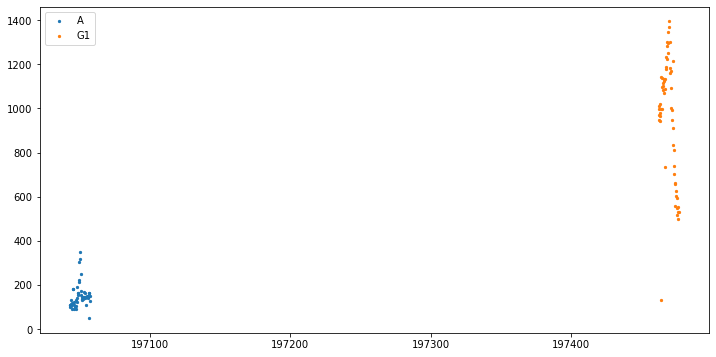

In [893]:
plt.figure(figsize = (12, 6))
plt.scatter(freqs_A_Z1Y1_0429, cps_A_Z1Y1_0429,
            s = 5, label = 'A')
plt.scatter(freqs_G1_Z1Y1_0429, cps_G1_Z1Y1_0429,
            s = 5, label = 'G1')

plt.legend()
plt.show()

# SiC 

# Material Comparison

In [771]:
c = 299792458  # m/s
def freq_to_wavelength(f_GHz):
    return c / (f_GHz * 1e9) * 1e9  # → nm

def wavelength_to_freq(l_nm):
    return c / (l_nm * 1e-9) / 1e9  # → GHz

In [831]:
# SILICON
si = pd.read_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\silicon sandwich\20260422.csv',
                 dtype = None, index_col = 0)

f = si['measured_frequency']
f_si = f[si['chip'] == 'Er2022_16X_natSi_FZ14B']
r = si['counts_per_repetition']
r_si = r[si['chip'] == 'Er2022_16X_natSi_FZ14B']

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\2806717839.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  si = pd.read_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\silicon sandwich\20260422.csv',


In [ ]:
# SILICON CARBIDE
sic = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-03-17\sic\motor'))
ylims = [0, 1e6]
numBins = 200

# PROCESS DATA
fVp_sic, timeLimit_sic = process_motor(sic,
                           numBins = numBins,
                           ylims = ylims,
                           save = False,
                           dataID = 'sic_motor_run2',
                           savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-18\sic\motor')

# EXTRACT RELEVANT ARRAYS
f_sic = np.array(fVp_sic[fr'Frequencies (MHz)'])
r_sic = np.array(fVp_sic[fr'Counts over {timeLimit_sic * 1e3} ms'])

In [853]:
# Process data
caf_post = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-04-23\*'))
ylims = [0, 1e8]
numBins = 50

fVp_caf_post, timeLimit_caf_post = process_motor(caf_post,
                           numBins = numBins,
                           ylims = ylims,
                           save = False,
                           dataID = 'motor_scan_back',
                           savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-18\sic\motor')

fVp_caf_post.sort_values(by = 'Frequencies (MHz)')
f_caf_post = fVp_caf_post['Frequencies (MHz)']
r_caf_post = fVp_caf_post[f'Counts over {timeLimit_caf_post * 1e3} ms']

In [840]:
import heapq

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\750149254.py:6: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


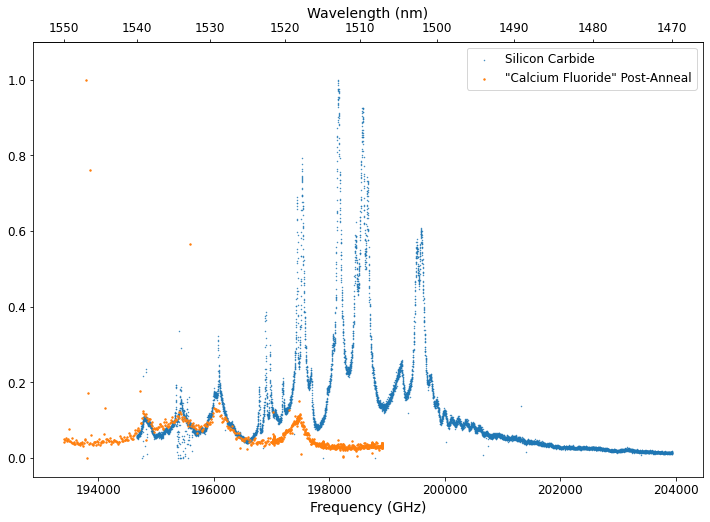

In [860]:
%matplotlib inline

fig, ax = plt.subplots(1, 1, figsize = (12, 8))
l2_sic = heapq.nlargest(2, r_sic)[1]

# ax.scatter(f_si, r_si/max(r_si), s = 0.2)
ax.scatter((f_sic + 410)/1e3, r_sic/l2_sic, s = 0.2,
           label = 'Silicon Carbide')
ax.scatter((f_caf_post + 410)/1e3, r_caf_post/max(r_caf_post), s = 2,
           label = fr'"Calcium Fluoride" Post-Anneal')
ax.tick_params(axis = 'both', labelsize = 12) 
ax.set_xlabel('Frequency (GHz)', fontsize = 14)

secax = ax.secondary_xaxis(
    'top',
    functions=(freq_to_wavelength, wavelength_to_freq)
)
secax.set_xlabel('Wavelength (nm)', fontsize = 14)
secax.tick_params(axis = 'x', labelsize = 12)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both')

plt.ylim([-0.05, 1.1])
# plt.xlim([193500, max(f_si)])
plt.legend(fontsize = 12)
plt.show()